This notebook is used to identify averaged conversion factor between Ni and Pd by looking at the relevant descriptors

In [3]:
import os
from pathlib import Path
import re #Import RegEx
import os
import math
import numpy as np
import pandas as pd
from pathlib import Path
import ast


import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt


In [4]:
ni_descriptor_df = pd.read_csv('ni_descriptor_data.csv')
pd_descriptor_df = pd.read_csv('descriptor_data.csv')

In [5]:
ni_descriptor_df

,Name,Metal,Atom_A,Atom_B,A-M-B Angle,M-A Distance,M-B Distance,Metal_NBO,A_NBO,B_NBO,...,% VBur asymm 2,% VBur asymm 3,% VBur octant 1,% VBur octant 2,% VBur octant 3,% VBur octant 4,% VBur octant 5,% VBur octant 6,% VBur octant 7,% VBur octant 8
0,ligand-005-c-n-1,1,2,59,91.32352,1.971,2.054,0.16442,0.24188,-0.40139,...,8.868338,35.680675,99.035594,44.376631,95.802274,60.207790,9.057026,27.087216,16.842154,51.281215
1,ligand-008-c-n-4,1,2,39,91.39589,1.945,2.060,0.15469,0.25273,-0.40638,...,3.845975,40.772922,99.249907,44.949683,95.816250,45.098770,0.983041,24.119456,14.773574,49.711144
2,ligand-011-c-n-7,1,2,22,87.75191,1.929,1.999,0.14921,0.29079,-0.39830,...,8.352357,10.017937,97.903466,86.302646,87.583861,84.420425,4.379426,4.547149,18.533358,43.673127
3,ligand-012-p-p-4,3,1,11,86.94115,2.236,2.248,-0.16007,1.15790,1.13718,...,1.603848,7.290114,88.934961,77.553112,98.788669,81.461983,11.018449,11.479687,10.580507,10.571189
4,ligand-014-p-c-1,2,1,47,84.85697,2.220,1.958,-0.09075,1.13562,0.31290,...,10.572354,24.479361,94.483787,53.727171,99.990682,83.572493,9.448379,20.844204,2.483228,31.830041
5,ligand-020-p-c-7,2,11,55,89.29466,2.224,1.916,-0.12867,1.18285,0.35318,...,7.907426,11.643915,99.636601,94.805255,96.230898,71.696795,5.096906,19.665486,11.591502,14.233135
6,ligand-032-p-p-11,3,12,1,97.25222,2.219,2.230,-0.17883,1.15213,1.13882,...,2.312011,4.532007,94.269474,90.374581,98.229594,92.084420,16.977264,24.520127,14.931979,15.477078
7,ligand-038-p-o-2,46,1,5,90.26991,2.317,2.033,0.18615,1.07168,-0.93872,...,18.682445,5.124860,68.295751,80.348490,99.343086,72.661200,15.099702,36.032426,16.781588,1.719158
8,ligand-043-p-p-17,3,12,1,88.21463,2.280,2.253,-0.09283,1.10484,1.10909,...,8.072820,6.006569,99.170704,97.535408,97.754379,87.099329,24.762393,42.266120,33.912598,28.144801
9,ligand-053-p-c-18,45,19,46,85.36525,2.246,1.911,-0.11415,1.14587,0.35994,...,8.411759,19.318394,74.655237,99.021618,79.742825,95.168654,10.081998,3.694558,35.836750,4.742825


In [6]:
# Identify overlapping ligand names, and then extract the descriptors for it.
pd_common_df = pd_descriptor_df[pd_descriptor_df['Name'].isin(ni_descriptor_df['Name'])]
# Generate PCA for each Pd/Ni dataset
# Generate 

In [7]:
pd_common_df

,Name,Metal,Atom_A,Atom_B,A-M-B Angle,M-A Distance,M-B Distance,Metal_NBO,A_NBO,B_NBO,...,% VBur asymm 2,% VBur asymm 3,% VBur octant 1,% VBur octant 2,% VBur octant 3,% VBur octant 4,% VBur octant 5,% VBur octant 6,% VBur octant 7,% VBur octant 8
4,ligand-005-c-n-1,1,2,59,86.57124,2.143,2.295,0.17756,0.22924,-0.40636,...,15.149786,30.368291,64.340291,88.292024,40.775252,96.850540,44.781960,9.821096,17.815878,11.330600
7,ligand-008-c-n-4,1,2,39,86.57287,2.138,2.268,0.17140,0.23752,-0.40746,...,8.268496,30.987933,52.129146,85.738912,45.355013,91.273761,32.850354,0.256243,15.477078,3.647969
10,ligand-011-c-n-7,1,2,22,83.16157,2.147,2.263,0.15382,0.24534,-0.41020,...,10.818114,15.160268,96.389303,73.984346,83.381476,75.773388,1.169400,2.245621,11.237421,40.789228
12,ligand-014-p-c-1,2,1,47,80.81116,2.386,2.134,-0.03138,1.10403,0.29668,...,3.285734,13.279212,64.410175,81.215058,80.115542,92.829855,21.775997,1.360417,6.699590,3.517518
18,ligand-020-p-c-7,2,11,55,85.96424,2.399,2.132,-0.07515,1.12753,0.30362,...,4.236163,8.862514,89.810846,82.682631,94.092434,80.143496,6.163809,18.412225,2.222326,4.346813
25,ligand-032-p-p-11,3,12,1,94.75609,2.408,2.403,-0.10610,1.07625,1.08540,...,1.538623,6.784616,86.568207,84.867685,94.772643,87.001491,8.647037,17.522363,9.145546,17.937011
30,ligand-038-p-o-2,46,1,5,88.61458,2.451,2.262,0.20609,1.04636,-0.95548,...,20.219903,7.337868,98.443906,65.262766,65.337309,77.338800,14.466083,0.703504,9.755870,31.690272
34,ligand-043-p-p-17,3,12,1,86.11174,2.433,2.418,0.00792,1.05104,1.05880,...,4.742825,4.856970,98.001305,94.712076,94.488446,85.529258,21.342713,31.583116,27.702199,24.641260
39,ligand-053-p-c-18,45,19,46,82.20175,2.421,2.131,-0.03167,1.09477,0.32120,...,10.143729,18.790766,70.546031,97.512113,72.894148,87.299665,4.644987,1.756429,31.643682,0.740775
42,ligand-056-p-c-21,69,46,18,98.31253,2.411,2.145,-0.07770,1.30153,0.31764,...,2.936312,3.064433,77.334141,80.842341,92.657473,85.757548,17.923034,10.766865,12.080693,3.587402


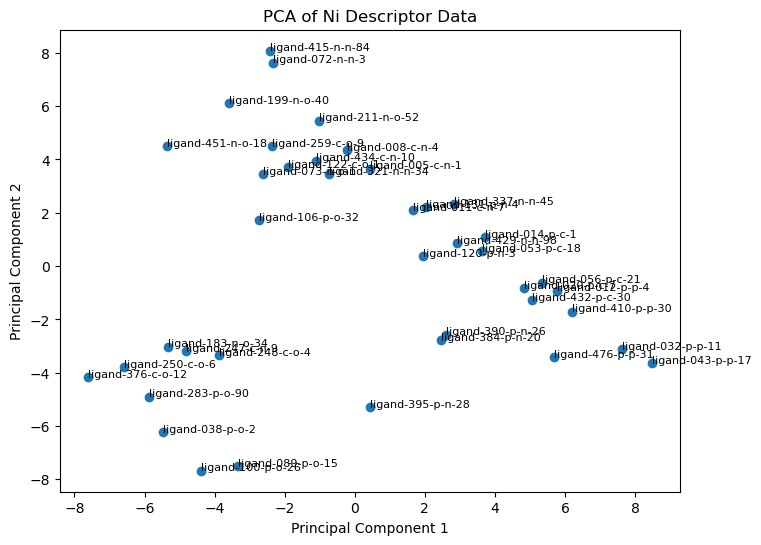

Explained variance ratio: [0.20944379 0.19193454]
Top features contributing to PC1:
B_NBO                  0.205312
B_mulliken             0.197836
% VBur min             0.157120
Total % VBur           0.137549
NBO-metal-a-diff       0.134788
                         ...   
Mulliken-dist-2-avg   -0.191120
NBO-dist-2-max        -0.192103
NBO-dist-2-b-min      -0.195038
NBO-dist-2-b-avg      -0.196511
NBO-dist-2-avg        -0.201465
Name: PC1, Length: 86, dtype: float64
Top features contributing to PC2:
NBO-dist-3-b-avg           0.173440
NBO-dist-3-b-min           0.171849
NBO-dist-3-min             0.161633
NBO-dist-2-a-min           0.160185
NBO-dist-2-min             0.158982
                             ...   
NBO-dist-2-a-b-diff       -0.160601
A_mulliken                -0.164817
NBO-dist-3-2-b-avg-diff   -0.169772
NBO-dist-4-3-a-avg-diff   -0.169974
NBO-dist-2-1-b-avg-diff   -0.187048
Name: PC2, Length: 86, dtype: float64


In [14]:
# Create PCA for Ni 
# Assume 'df' is your DataFrame
features = ni_descriptor_df.drop(columns=['Name'])  # or any other non-numeric columns
scaler = StandardScaler()
X_scaled = scaler.fit_transform(features)
pca = PCA(n_components=2)  # change to more components if needed
X_pca = pca.fit_transform(X_scaled)
ni_pca_df = pd.DataFrame(data=X_pca, columns=['PC1', 'PC2'])
ni_pca_df['Name'] = ni_descriptor_df['Name'].values

plt.figure(figsize=(8, 6))
plt.scatter(ni_pca_df['PC1'], ni_pca_df['PC2'])

# Optional: label the points
for i, name in enumerate(ni_pca_df['Name']):
    plt.text(ni_pca_df['PC1'][i], ni_pca_df['PC2'][i], name, fontsize=8)

plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA of Ni Descriptor Data')
plt.grid(False)
plt.show()

print("Explained variance ratio:", pca.explained_variance_ratio_)


#Obtain loadings
# Get the feature names used in PCA
feature_names = features.columns  # These are the original descriptors

# Get loadings (PCA components)
loadings = pd.DataFrame(
    pca.components_.T,                      # transpose so rows = features, columns = PCs
    columns=['PC1', 'PC2'],                 # match your PCA component names
    index=feature_names                     # label rows with feature names
)

sorted_pc1 = loadings['PC1'].sort_values(ascending=False)
print("Top features contributing to PC1:")
print(sorted_pc1)

sorted_pc2 = loadings['PC2'].sort_values(ascending=False)
print("Top features contributing to PC2:")
print(sorted_pc2)

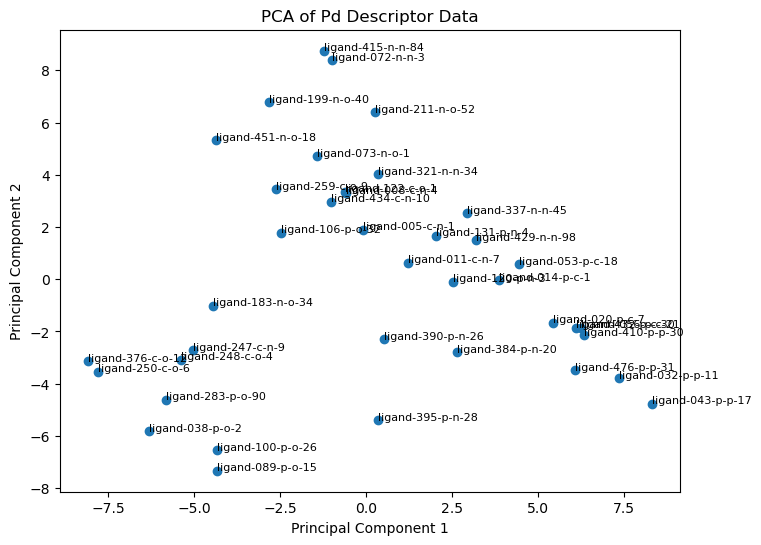

Explained variance ratio: [0.21945916 0.19689292]
Top features contributing to PC1:
B_NBO                0.202977
B_mulliken           0.195731
% VBur min           0.159797
NBO-dist-3-b-avg     0.141706
% VBur NW SW diff    0.136892
                       ...   
NBO-dist-2-avg      -0.190146
NBO-dist-2-b-max    -0.195964
NBO-dist-2-max      -0.196844
NBO-dist-2-b-min    -0.198308
NBO-dist-2-b-avg    -0.201101
Name: PC1, Length: 86, dtype: float64
Top features contributing to PC2:
NBO-dist-2-a-min           0.181108
NBO-dist-2-min             0.179990
NBO-dist-2-a-avg           0.173497
Metal_mullkien             0.155137
NBO-dist-2-a-max           0.153131
                             ...   
Total % VBur              -0.157774
NBO-dist-4-3-a-avg-diff   -0.158390
NBO-dist-2-1-b-avg-diff   -0.161898
A_NBO                     -0.176625
A_mulliken                -0.181756
Name: PC2, Length: 86, dtype: float64


In [15]:
# Create PCA for Pd
# Assume 'df' is your DataFrame
features = pd_common_df.drop(columns=['Name'])  # or any other non-numeric columns
scaler = StandardScaler()
X_scaled = scaler.fit_transform(features)
pca = PCA(n_components=2)  # change to more components if needed
X_pca = pca.fit_transform(X_scaled)
pd_pca_df = pd.DataFrame(data=X_pca, columns=['PC1', 'PC2'])
pd_pca_df['Name'] = pd_common_df['Name'].values


plt.figure(figsize=(8, 6))
plt.scatter(pd_pca_df['PC1'], pd_pca_df['PC2'])

# Optional: label the points
for i, name in enumerate(pd_pca_df['Name']):
    plt.text(pd_pca_df['PC1'][i], pd_pca_df['PC2'][i], name, fontsize=8)

plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA of Pd Descriptor Data')
plt.grid(False)
plt.show()

print("Explained variance ratio:", pca.explained_variance_ratio_)

#Obtain loadings
# Get the feature names used in PCA
feature_names = features.columns  # These are the original descriptors

# Get loadings (PCA components)
loadings = pd.DataFrame(
    pca.components_.T,                      # transpose so rows = features, columns = PCs
    columns=['PC1', 'PC2'],                 # match your PCA component names
    index=feature_names                     # label rows with feature names
)

sorted_pc1 = loadings['PC1'].sort_values(ascending=False)
print("Top features contributing to PC1:")
print(sorted_pc1)

sorted_pc2 = loadings['PC2'].sort_values(ascending=False)
print("Top features contributing to PC2:")
print(sorted_pc2)

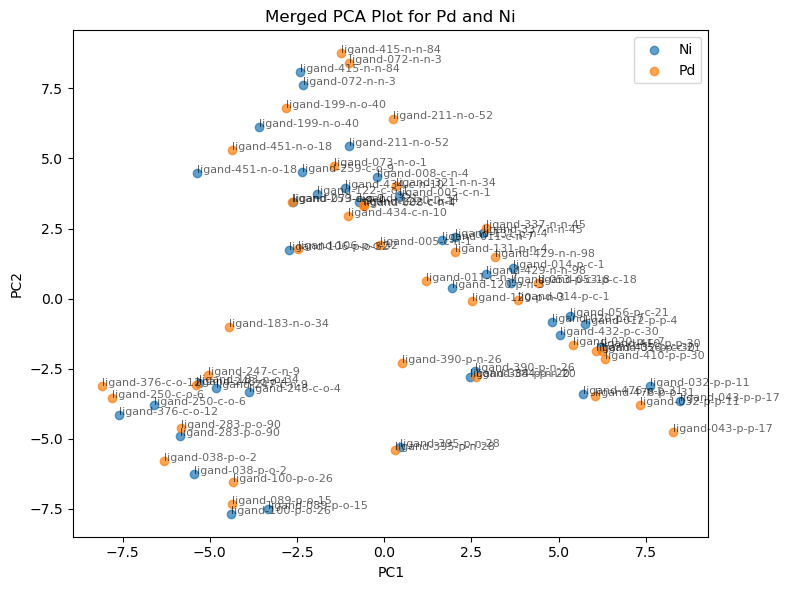

In [11]:
ni_pca_df['Group'] = 'Ni'
pd_pca_df['Group'] = 'Pd'

#Combine two dataframes
combined_pca_df = pd.concat([ni_pca_df, pd_pca_df], ignore_index=True)

# Set figure size
plt.figure(figsize=(8, 6))

# Plot each group with a different color
for group, subset in combined_pca_df.groupby('Group'):
    plt.scatter(subset['PC1'], subset['PC2'], label=group, alpha=0.7)

# Add labels
for _, row in combined_pca_df.iterrows():
    plt.text(row['PC1'], row['PC2'], row['Name'], fontsize=8, alpha=0.6)

# Customize plot
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('Merged PCA Plot for Pd and Ni')
plt.legend()
plt.grid(False)  # Removes grid
plt.tight_layout()

plt.savefig("pd_ni_merge_pca.png", dpi=600, bbox_inches='tight')
plt.show()


In [12]:
combined_pca_df

,PC1,PC2,Name,Group
0,0.432201,3.646664,ligand-005-c-n-1,Ni
1,-0.217101,4.352402,ligand-008-c-n-4,Ni
2,1.660037,2.103256,ligand-011-c-n-7,Ni
3,5.771283,-0.922456,ligand-012-p-p-4,Ni
4,3.705197,1.079138,ligand-014-p-c-1,Ni
...,...,...,...,...
74,3.181741,1.497112,ligand-429-n-n-98,Pd
75,6.082683,-1.854827,ligand-432-p-c-30,Pd
76,-1.039024,2.963626,ligand-434-c-n-10,Pd
77,-4.371839,5.315535,ligand-451-n-o-18,Pd


In [13]:
from scipy.spatial.distance import pdist, squareform

# Use PC1 and PC2 for distance calculations
coords = combined_pca_df[['PC1', 'PC2']].values

# Compute Euclidean distance matrix
distance_matrix = squareform(pdist(coords, metric='euclidean'))

# Create row and column labels using Name + Group
labels = combined_pca_df['Name'] + ' (' + combined_pca_df['Group'] + ')'

# Convert to a labeled DataFrame
distance_df = pd.DataFrame(distance_matrix, index=labels, columns=labels)


# Optionally, show a subset
distance_df


,ligand-005-c-n-1 (Ni),ligand-008-c-n-4 (Ni),ligand-011-c-n-7 (Ni),ligand-012-p-p-4 (Ni),ligand-014-p-c-1 (Ni),ligand-020-p-c-7 (Ni),ligand-032-p-p-11 (Ni),ligand-038-p-o-2 (Ni),ligand-043-p-p-17 (Ni),ligand-053-p-c-18 (Ni),...,ligand-384-p-n-20 (Pd),ligand-390-p-n-26 (Pd),ligand-395-p-n-28 (Pd),ligand-410-p-p-30 (Pd),ligand-415-n-n-84 (Pd),ligand-429-n-n-98 (Pd),ligand-432-p-c-30 (Pd),ligand-434-c-n-10 (Pd),ligand-451-n-o-18 (Pd),ligand-476-p-p-31 (Pd)
ligand-005-c-n-1 (Ni),0.000000,0.958989,1.972229,7.027279,4.159891,6.258957,9.876102,11.511592,10.848880,4.451022,...,6.801847,5.940561,9.041145,8.258052,5.369137,3.490063,7.886339,1.622049,5.085659,9.088263
ligand-008-c-n-4 (Ni),0.958989,0.000000,2.929558,7.980280,5.108687,7.217515,10.832839,11.821128,11.804250,5.408701,...,7.689450,6.685154,9.761285,9.215931,4.514375,4.439010,8.844036,1.613771,4.264912,10.044728
ligand-011-c-n-7 (Ni),1.972229,2.929558,0.000000,5.104633,2.287246,4.302248,7.929182,10.970770,8.908315,2.508223,...,4.988243,4.545379,7.615108,6.305244,7.250087,1.637984,5.935168,2.832872,6.833905,7.116059
ligand-012-p-p-4 (Ni),7.027279,7.980280,5.104633,0.000000,2.876646,0.960646,2.876035,12.428936,3.829707,2.599143,...,3.650701,5.439941,7.046964,1.336282,11.943273,3.544015,0.982998,7.841040,11.907790,2.584640
ligand-014-p-c-1 (Ni),4.159891,5.108687,2.287246,2.876646,0.000000,2.200678,5.745249,11.731527,6.706051,0.534422,...,4.013777,4.647913,7.302598,4.149413,9.123992,0.669857,3.776320,5.104794,9.120612,5.140294
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ligand-429-n-n-98 (Pd),3.490063,4.439010,1.637984,3.544015,0.669857,2.835972,6.408672,11.601717,7.372445,1.047542,...,4.321003,4.639266,7.459794,4.806142,8.491893,0.000000,4.432941,4.468279,8.463860,5.758029
ligand-432-p-c-30 (Pd),7.886339,8.844036,5.935168,0.982998,3.776320,1.635234,1.995287,12.349989,2.980854,3.435353,...,3.573131,5.592975,6.758714,0.373208,12.884445,4.432941,0.000000,8.598616,12.677189,1.636521
ligand-434-c-n-10 (Pd),1.622049,1.613771,2.832872,7.841040,5.104794,6.971531,10.586768,10.212565,11.577022,5.255518,...,6.825155,5.479653,8.467981,8.958967,5.790478,4.468279,8.598616,0.000000,4.079109,9.593225
ligand-451-n-o-18 (Pd),5.085659,4.264912,6.833905,11.907790,9.120612,11.048504,14.665871,11.608308,15.656044,9.312959,...,10.712756,9.038734,11.693896,13.037972,4.652893,8.463860,12.677189,4.079109,0.000000,13.650509


In [14]:
# Assuming you have already created 'combined_pca_df'

# Calculate the range for PC1 and PC2
pc1_range = combined_pca_df['PC1'].max() - combined_pca_df['PC1'].min()
pc2_range = combined_pca_df['PC2'].max() - combined_pca_df['PC2'].min()

# Print the results
print(f"PC1 Range: {pc1_range}")
print(f"PC2 Range: {pc2_range}")

max_range = math.sqrt(pc1_range**2 + pc2_range**2)
print(f"Maximum diagonal distance: {max_range}")

percent_distance_df = (distance_df/max_range)*100
percent_distance_df


PC1 Range: 16.56483285357247
PC2 Range: 16.42594475262635
Maximum diagonal distance: 23.328209285822325


,ligand-005-c-n-1 (Ni),ligand-008-c-n-4 (Ni),ligand-011-c-n-7 (Ni),ligand-012-p-p-4 (Ni),ligand-014-p-c-1 (Ni),ligand-020-p-c-7 (Ni),ligand-032-p-p-11 (Ni),ligand-038-p-o-2 (Ni),ligand-043-p-p-17 (Ni),ligand-053-p-c-18 (Ni),...,ligand-384-p-n-20 (Pd),ligand-390-p-n-26 (Pd),ligand-395-p-n-28 (Pd),ligand-410-p-p-30 (Pd),ligand-415-n-n-84 (Pd),ligand-429-n-n-98 (Pd),ligand-432-p-c-30 (Pd),ligand-434-c-n-10 (Pd),ligand-451-n-o-18 (Pd),ligand-476-p-p-31 (Pd)
ligand-005-c-n-1 (Ni),0.000000,4.110856,8.454269,30.123526,17.832018,26.829995,42.335450,49.346231,46.505411,19.079998,...,29.157174,25.465140,38.756275,35.399426,23.015643,14.960699,33.806021,6.953165,21.800470,38.958252
ligand-008-c-n-4 (Ni),4.110856,0.000000,12.558004,34.208714,21.899180,30.939003,46.436651,50.673105,50.600755,23.185238,...,32.962024,28.656952,41.843269,39.505521,19.351570,19.028506,37.911337,6.917681,18.282208,43.058288
ligand-011-c-n-7 (Ni),8.454269,12.558004,0.000000,21.881803,9.804638,18.442254,33.989674,47.027914,38.186881,10.751887,...,21.382881,19.484476,32.643345,27.028409,31.078628,7.021475,25.442021,12.143548,29.294599,30.504095
ligand-012-p-p-4 (Ni),30.123526,34.208714,21.881803,0.000000,12.331190,4.117959,12.328570,53.278570,16.416635,11.141631,...,15.649300,23.319153,30.207910,5.728179,51.196698,15.191970,4.213775,33.611840,51.044594,11.079461
ligand-014-p-c-1 (Ni),17.832018,21.899180,9.804638,12.331190,0.000000,9.433548,24.627904,50.289015,28.746530,2.290885,...,17.205680,19.924002,31.303721,17.787103,39.111410,2.871447,16.187783,21.882495,39.096923,22.034672
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ligand-429-n-n-98 (Pd),14.960699,19.028506,7.021475,15.191970,2.871447,12.156836,27.471769,49.732564,31.603132,4.490451,...,18.522652,19.886937,31.977566,20.602277,36.401819,0.000000,19.002490,19.153973,36.281651,24.682686
ligand-432-p-c-30 (Pd),33.806021,37.911337,25.442021,4.213775,16.187783,7.009685,8.553110,52.940150,12.777896,14.726177,...,15.316780,23.975158,28.972278,1.599816,55.231178,19.002490,0.000000,36.859306,54.342743,7.015202
ligand-434-c-n-10 (Pd),6.953165,6.917681,12.143548,33.611840,21.882495,29.884553,45.381830,43.777750,49.626706,22.528595,...,29.257088,23.489384,36.299320,38.404006,24.821785,19.153973,36.859306,0.000000,17.485736,41.122852
ligand-451-n-o-18 (Pd),21.800470,18.282208,29.294599,51.044594,39.096923,47.361131,62.867540,49.760821,67.112071,39.921450,...,45.921896,38.745940,50.127706,55.889295,19.945352,36.281651,54.342743,17.485736,0.000000,58.515033


In [15]:
import pandas as pd

# Extract base names and groups from labels
row_labels = distance_df.index
col_labels = distance_df.columns

def extract_name_and_group(label):
    name, group = label.strip(')').split(' (')
    return name, group

# Create a list of matching name-different group pairs
matching_pairs = []

for row_label in row_labels:
    name1, group1 = extract_name_and_group(row_label)
    for col_label in col_labels:
        name2, group2 = extract_name_and_group(col_label)
        if name1 == name2 and group1 != group2:
            matching_pairs.append((row_label, col_label))

# Create a DataFrame for the filtered results
filtered_distances = []

for r, c in matching_pairs:
    value = distance_df.loc[r, c]
    filtered_distances.append({
        'Name': extract_name_and_group(r)[0],
        'Group 1': extract_name_and_group(r)[1],
        'Group 2': extract_name_and_group(c)[1],
        'Distance': value
    })

result_df = pd.DataFrame(filtered_distances)
result_df['%_difference'] = (result_df['Distance']/max_range)*100

In [16]:
result_df

,Name,Group 1,Group 2,Distance,%_difference
0,ligand-005-c-n-1,Ni,Pd,1.833858,7.861117
1,ligand-008-c-n-4,Ni,Pd,1.123744,4.817105
2,ligand-011-c-n-7,Ni,Pd,1.532585,6.569662
3,ligand-014-p-c-1,Ni,Pd,1.125720,4.825576
4,ligand-020-p-c-7,Ni,Pd,1.032535,4.426122
...,...,...,...,...,...
73,ligand-429-n-n-98,Pd,Ni,0.683182,2.928564
74,ligand-432-p-c-30,Pd,Ni,1.174234,5.033535
75,ligand-434-c-n-10,Pd,Ni,0.992871,4.256097
76,ligand-451-n-o-18,Pd,Ni,1.283910,5.503682


In [17]:
# Step 1: Extract the donor atom class (e.g., 'c-n') from the ligand name
def extract_class(name):
    parts = name.split('-')
    return f"{parts[2]}-{parts[3]}"  # Adjust indices if format differs

# Step 2: Apply the function to create a new 'Class' column
result_df['Class'] = result_df['Name'].apply(extract_class)

# Step 3: Group by class and calculate the average %_difference
avg_diff_by_class = result_df.groupby('Class')['%_difference'].mean().reset_index()

# Optional: Sort by average % difference
avg_diff_by_class = avg_diff_by_class.sort_values(by='%_difference', ascending=False)


In [18]:
avg_diff_by_class

,Class,%_difference
3,n-o,6.709299
1,c-o,5.441155
0,c-n,5.140176
4,p-c,4.851769
2,n-n,4.317167
5,p-n,3.203043
6,p-o,3.136685
7,p-p,2.891136


In [13]:
import pandas as pd
master_ligand_dataset_df = pd.read_csv('master_ligand_dataset_4.csv')
master_ligand_dataset_df = master_ligand_dataset_df.dropna(subset=['lig_id'])

In [14]:
master_ligand_dataset_df

,lig_id,ligand_name,SMILES,exp_id,ref,substrate_comb,metal,substrate_1,substrate_1_smiles,substrate_2,...,incorporatio_ratio,ton,Unnamed: 27,Unnamed: 28,Unnamed: 29,Unnamed: 30,Unnamed: 31,Unnamed: 32,Unnamed: 33,Unnamed: 34
0,1.0,n-n-1,CN(CCN(C)C)C,1.0,"ChemSusChem, 2011, 4, 1275 – 1279",CO2ethylene,Ni,CO2,NaN,ethylene,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1.0,n-n-1,CN(CCN(C)C)C,2.0,"ChemSusChem, 2011, 4, 1275 – 1279",CO2ethylene,Ni,CO2,NaN,ethylene,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2.0,p-p-1,P(CCP(C1=CC=CC=C1)C2=CC=CC=C2)(C3=CC=CC=C3)C4=...,3.0,"ChemSusChem, 2011, 4, 1275 – 1279",CO2ethylene,Ni,CO2,NaN,ethylene,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2.0,p-p-1,P(CCP(C1=CC=CC=C1)C2=CC=CC=C2)(C3=CC=CC=C3)C4=...,4.0,"ChemSusChem, 2011, 4, 1275 – 1279",CO2ethylene,Ni,CO2,NaN,ethylene,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,3.0,p-p-2,P(CCCP(C1=CC=CC=C1)C2=CC=CC=C2)(C3=CC=CC=C3)C4...,5.0,"ChemSusChem, 2011, 4, 1275 – 1279",CO2ethylene,Ni,CO2,NaN,ethylene,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2138,480.0,p-p-35,dippf,2152.0,"GreenChem., 2010, 12, 381–383",Ar-XPhMgBr,Pd,Ar-X,NaN,PhMgBr,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2139,476.0,p-p-31,dtbpf,2153.0,"GreenChem., 2010, 12, 381–383",Ar-XPhMgBr,Pd,Ar-X,NaN,PhMgBr,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2140,2.0,p-p-1,P(CCP(C1=CC=CC=C1)C2=CC=CC=C2)(C3=CC=CC=C3)C4=...,2154.0,"GreenChem., 2010, 12, 381–383",Ar-XPhMgBr,Pd,Ar-X,NaN,PhMgBr,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2141,4.0,p-p-3,P(CCCCP(C1=CC=CC=C1)C2=CC=CC=C2)(C3=CC=CC=C3)C...,2155.0,"GreenChem., 2010, 12, 381–383",Ar-XPhMgBr,Pd,Ar-X,NaN,PhMgBr,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [15]:
df_filtered = master_ligand_dataset_df[['ligand_name', 'substrate_comb', 'metal']].drop_duplicates()


In [16]:
df_filtered

,ligand_name,substrate_comb,metal
0,n-n-1,CO2ethylene,Ni
2,p-p-1,CO2ethylene,Ni
4,p-p-2,CO2ethylene,Ni
6,p-p-3,CO2ethylene,Ni
8,c-n-1,CO2ethylene,Ni
...,...,...,...
2138,p-p-35,Ar-XPhMgBr,Pd
2139,p-p-31,Ar-XPhMgBr,Pd
2140,p-p-1,Ar-XPhMgBr,Pd
2141,p-p-3,Ar-XPhMgBr,Pd


In [18]:
pd_ni_lig_rxn = df_filtered[df_filtered.duplicated(subset=['ligand_name', 'substrate_comb'], keep=False)]
pd_ni_lig_rxn

,ligand_name,substrate_comb,metal
22,p-p-4,CO2ethylene,Ni
208,p-o-15,ethylenenone,Ni
217,p-o-16,ethylenenone,Ni
223,p-o-17,ethylenenone,Ni
229,p-o-15,ethylenemethyl acrylate,Ni
...,...,...,...
2016,p-o-150,ethylenenone,Ni
2017,p-o-151,ethylenenone,Ni
2018,p-o-152,ethylenenone,Ni
2094,p-p-34,Ar-XR-NH2,Ni


In [19]:
duplicate_groups = df_filtered[df_filtered.duplicated(subset=['ligand_name', 'substrate_comb'], keep=False)]
metal_variation = duplicate_groups.groupby(['ligand_name', 'substrate_comb'])['metal'].unique().reset_index()
metal_variation['metal'] = metal_variation['metal'].apply(list)  # Convert to list if it's a NumPy array




In [20]:
metal_variation

,ligand_name,substrate_comb,metal
0,c-o-1,ethyleneacrylonitrile,"[Ni, Pd]"
1,c-o-1,ethyleneallyl acetate,"[Ni, Pd]"
2,c-o-1,ethylenemethyl acrylate,"[Ni, Pd]"
3,c-o-1,ethylenenone,"[Ni, Pd]"
4,n-n-82,Ar-XR-B(OH)2,"[Pd, Ni]"
5,n-o-37,ethylenenone,"[Ni, Pd]"
6,n-o-38,ethylenenone,"[Ni, Pd]"
7,n-o-39,ethylenenone,"[Ni, Pd]"
8,p-n-1,ethylenenone,"[Ni, Pd]"
9,p-n-4,ethylenenone,"[Ni, Pd]"
